# Logistic Regression and SVM


## 1. What is a classification?

Classification is a **supervised** learning task:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}, \qquad y_i \in \{0, 1, \dots, K-1\}
$$

We already know the correct label during training and want a rule

$$
\hat{y} = f(x)
$$

that generalizes to new objects.

For binary classification, we often care about

$$
P(y=1 \mid x)
$$

Typical examples: spam vs not spam, churn vs stay, benign vs malignant.


In [20]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    load_breast_cancer,
    load_wine,
    make_classification,
    make_moons,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC, SVC

In [21]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)

ink = "#2f2a34"
paper = "#f6f1e7"
panel = "#efe4d6"
grid = "#ccbda8"

sns.set_theme(
    context="talk",
    style="ticks",
    palette=["#ff6b6b", "#1982c4", "#ffd166", "#2a9d8f", "#6a4c93"],
    rc={
        "figure.facecolor": paper,
        "axes.facecolor": panel,
        "savefig.facecolor": paper,
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "text.color": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "grid.color": grid,
        "grid.linestyle": ":",
        "grid.alpha": 0.55,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "legend.frameon": True,
        "legend.facecolor": "#fbf7f0",
        "legend.edgecolor": grid,
    },
)

surface_cmap = sns.blend_palette(
    ["#1f2041", "#4b3f72", "#417b5a", "#f4d35e", "#ee964b"], as_cmap=True
)
warm_cmap = sns.blend_palette(["#fff1d0", "#f4a261", "#e76f51"], as_cmap=True)
cool_cmap = sns.blend_palette(["#e0fbfc", "#4ea8de", "#293241"], as_cmap=True)
class_colors = ["#ff6b6b", "#1982c4", "#6a4c93", "#2a9d8f"]


def metric_frame(y_true, y_pred, y_score=None):
    rows = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        rows["roc_auc"] = roc_auc_score(y_true, y_score)
    return pd.DataFrame(
        {"metric": list(rows.keys()), "value": list(rows.values())}
    )


def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def final_estimator(model):
    return model.named_steps["model"] if isinstance(model, Pipeline) else model


def scaler_step(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get("scaler")
    return None


def score_on_grid(model, grid):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(grid)[:, 1]
    scores = model.decision_function(grid)
    min_score, max_score = scores.min(), scores.max()
    return (scores - min_score) / (max_score - min_score)


def plot_surface(ax, model, X, y, title, show_support=False, levels=28):
    xx, yy, grid = make_grid(X)
    z = score_on_grid(model, grid).reshape(xx.shape)

    ax.contourf(xx, yy, z, levels=levels, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors="#fffaf1", linewidths=2.2)
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def plot_margin_surface(ax, model, X, y, title, show_support=True):
    xx, yy, grid = make_grid(X)
    scores = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, scores, levels=28, cmap=surface_cmap, alpha=0.92)
    ax.contour(
        xx,
        yy,
        scores,
        levels=[-1, 0, 1],
        colors=["#f4d35e", "#fffaf1", "#4ecdc4"],
        linestyles=["--", "-", "--"],
        linewidths=[1.6, 2.3, 1.6],
    )
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def annotate_bars(ax, offset=None, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim()
    delta = (ymax - ymin) * 0.02 if offset is None else offset
    for patch in ax.patches:
        value = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + delta,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=10,
        )


print("Theme loaded. Notebook ready.")


Theme loaded. Notebook ready.


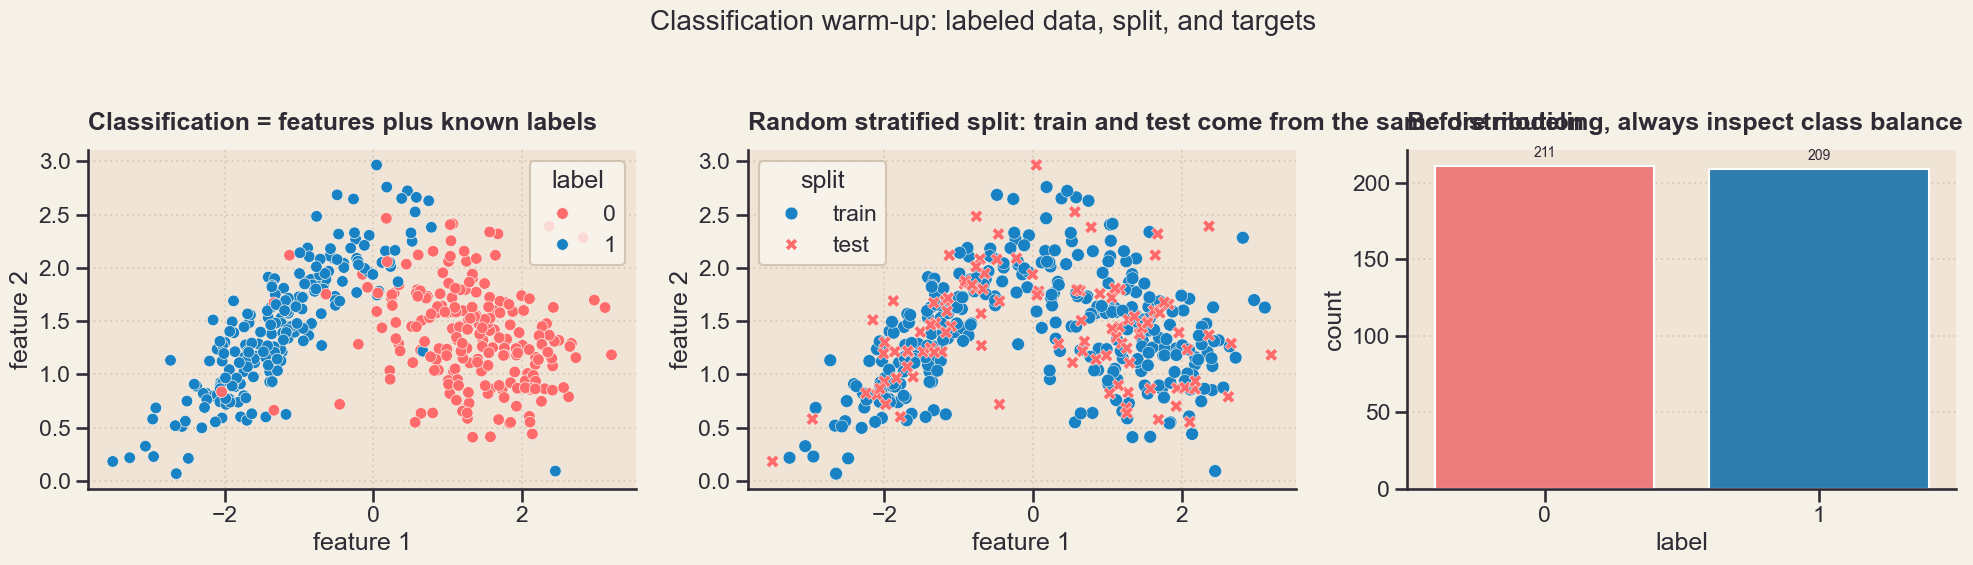

,feature_1,feature_2,label
0,-1.106698,1.660291,1
1,1.385041,1.551358,0
2,0.051365,1.744050,1
3,-0.223663,2.089217,1
4,1.764512,1.676605,0


In [22]:
X_intro, y_intro = make_classification(
    n_samples=420,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.35,
    flip_y=0.03,
    random_state=21,
)

X_train_intro, X_test_intro, y_train_intro, y_test_intro = train_test_split(
    X_intro,
    y_intro,
    test_size=0.25,
    stratify=y_intro,
    random_state=42,
)

intro_frame = pd.DataFrame(X_intro, columns=["feature_1", "feature_2"])
intro_frame["label"] = y_intro

split_frame = pd.DataFrame(
    np.vstack([X_train_intro, X_test_intro]),
    columns=["feature_1", "feature_2"],
)
split_frame["label"] = np.hstack([y_train_intro, y_test_intro])
split_frame["split"] = ["train"] * len(X_train_intro) + ["test"] * len(X_test_intro)

balance_frame = (
    intro_frame["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

sns.scatterplot(
    data=intro_frame,
    x="feature_1",
    y="feature_2",
    hue="label",
    palette=class_colors[:2],
    s=70,
    edgecolor=paper,
    linewidth=0.5,
    ax=axes[0],
)
axes[0].set_title("Classification = features plus known labels")
axes[0].set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")
axes[0].legend(title="label", loc="upper right")

sns.scatterplot(
    data=split_frame,
    x="feature_1",
    y="feature_2",
    hue="split",
    style="split",
    palette={"train": "#1982c4", "test": "#ff6b6b"},
    markers={"train": "o", "test": "X"},
    s=85,
    edgecolor=paper,
    linewidth=0.4,
    ax=axes[1],
)
axes[1].set_title("Random stratified split: train and test come from the same distribution")
axes[1].set_xlabel("feature 1")
axes[1].set_ylabel("feature 2")

sns.barplot(
    data=balance_frame,
    x="label",
    y="count",
    hue="label",
    palette=class_colors[:2],
    dodge=False,
    legend=False,
    ax=axes[2],
)
annotate_bars(axes[2], offset=4, fmt="{:.0f}")
axes[2].set_title("Before modeling, always inspect class balance")
axes[2].set_xlabel("label")
axes[2].set_ylabel("count")

fig.suptitle("Classification warm-up: labeled data, split, and targets", y=1.04, fontsize=20)
fig.tight_layout()
plt.show()

intro_frame.head()


Now that the task is clear, we study two classic classification baselines:
- Logistic Regression: linear score, probabilistic output
- SVM: linear or kernel boundary, margin maximization

We start with Logistic Regression because probabilities are easy to interpret and threshold.


### Why study these two instead of a more powerful model?

- They are still strong baselines on many tabular classification problems.
- Logistic Regression teaches probabilities, log-odds, and thresholding.
- SVM teaches margins, support vectors, and the idea of kernels.
- Both are fast to train, easy to debug, and easier to explain than boosting or deep nets.
- If these simple models already work well, a more complex model may add little value.
- If they fail, that failure is informative: maybe the boundary is nonlinear, the features are weak, or the data needs better preprocessing.


## 2. Logistic Regression

Core equations:

$$
z = w^\top x + b
$$

$$
p(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

$$
\log \frac{p}{1-p} = w^\top x + b
$$

It is linear in feature space, but probabilistic at the output.


### Odds and why we compute them

Odds are not the same as probability:

$$
\text{odds} = \frac{p}{1-p}
$$

If $p=0.8$, then

$$
\text{odds} = \frac{0.8}{0.2} = 4
$$

which means the positive class is four times as likely as the negative class.

Why do we care?
- Logistic Regression is linear in **log-odds**, not in probability.
- Taking the logarithm turns multiplicative changes in odds into additive effects.
- This is why coefficients are easy to interpret through odds ratios like $\exp(w_j)$.


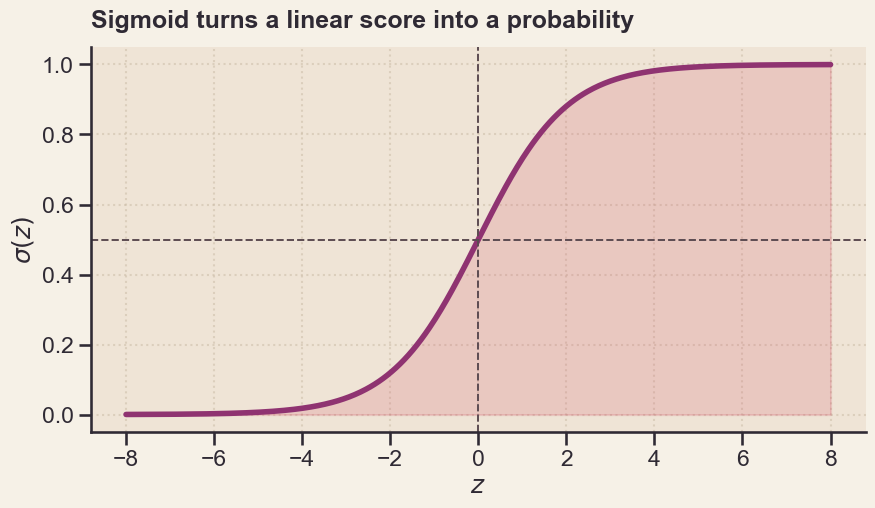

In [23]:
z = np.linspace(-8, 8, 500)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z, sigmoid, linewidth=4, color=sns.color_palette("flare", 6)[4])
ax.fill_between(z, 0, sigmoid, color=sns.color_palette("flare", 6)[2], alpha=0.18)
ax.axhline(0.5, color="#5c4b51", linestyle="--", linewidth=1.4)
ax.axvline(0.0, color="#5c4b51", linestyle="--", linewidth=1.4)
ax.set_title("Sigmoid turns a linear score into a probability")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\sigma(z)$")
plt.show()


Training objective:

$$
L(y, p) = -\left[y \log p + (1-y)\log(1-p)\right]
$$

The model is punished most when it is very confident and wrong.


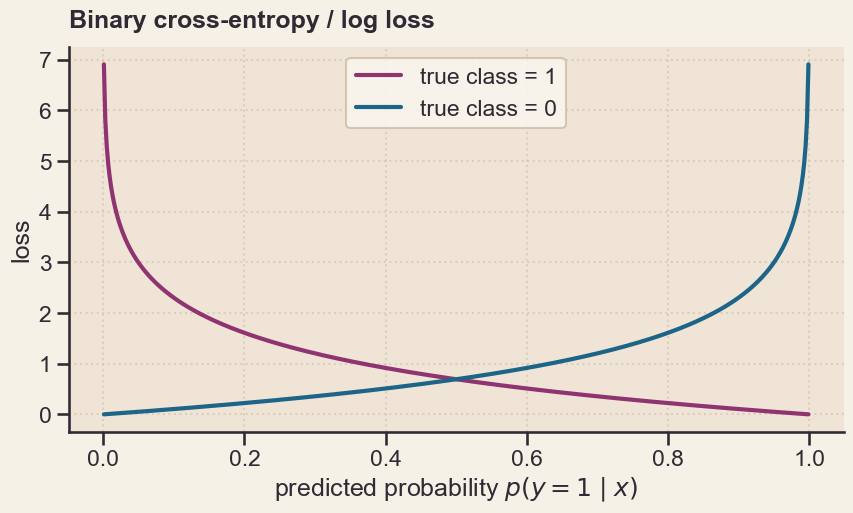

In [24]:
p = np.linspace(0.001, 0.999, 500)
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p, loss_y1, label=r"true class = 1", linewidth=3, color=sns.color_palette("flare", 6)[4])
ax.plot(p, loss_y0, label=r"true class = 0", linewidth=3, color=sns.color_palette("crest", 6)[4])
ax.set_title("Binary cross-entropy / log loss")
ax.set_xlabel(r"predicted probability $p(y=1 \mid x)$")
ax.set_ylabel("loss")
ax.legend(frameon=True)
plt.show()


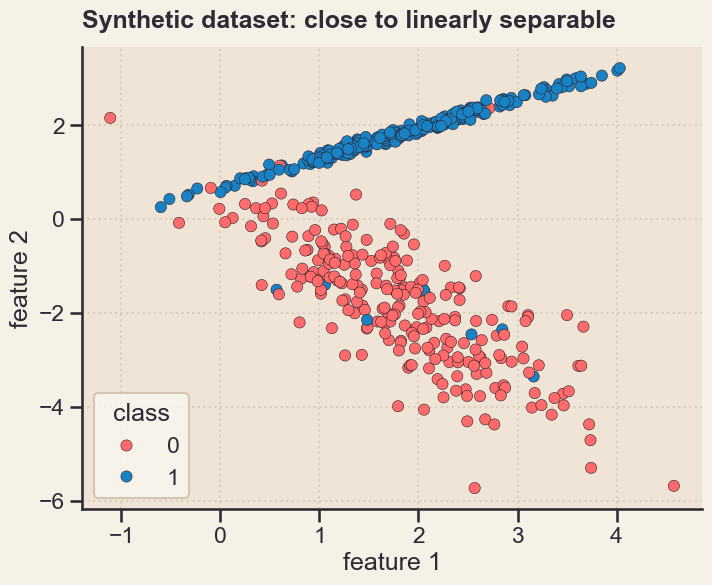

In [25]:
X_lin, y_lin = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.04,
    random_state=42,
)

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin,
    y_lin,
    test_size=0.25,
    stratify=y_lin,
    random_state=42,
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=X_lin[:, 0],
    y=X_lin[:, 1],
    hue=y_lin,
    palette=class_colors[:2],
    s=65,
    edgecolor="#2b1d26",
    linewidth=0.4,
    ax=ax,
)
ax.set_title("Synthetic dataset: close to linearly separable")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.legend(title="class")
plt.show()


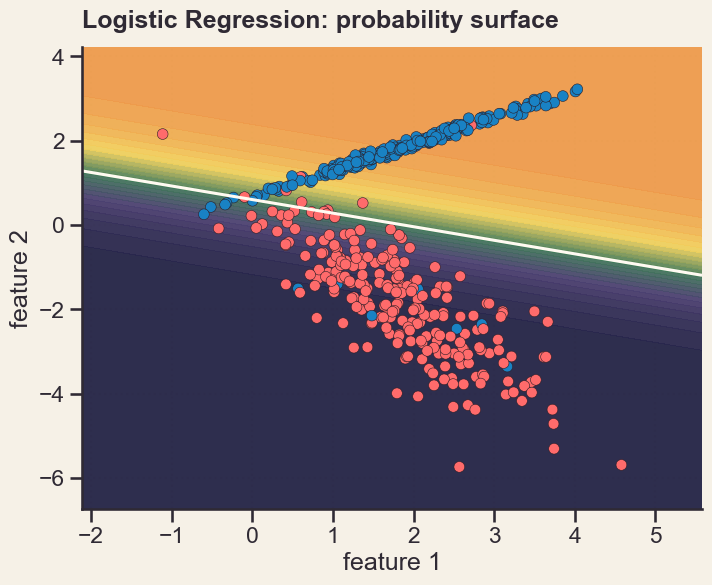

,metric,value
0,accuracy,0.952
1,precision,0.952
2,recall,0.952
3,f1,0.952
4,roc_auc,0.986


In [26]:
logreg_lin = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=2000)),
    ]
)
logreg_lin.fit(X_train_lin, y_train_lin)

pred_lin = logreg_lin.predict(X_test_lin)
proba_lin = logreg_lin.predict_proba(X_test_lin)[:, 1]

metrics_lin = metric_frame(y_test_lin, pred_lin, proba_lin)

fig, ax = plt.subplots(figsize=(8, 6))
plot_surface(ax, logreg_lin, X_lin, y_lin, "Logistic Regression: probability surface")
plt.show()

metrics_lin.round(3)


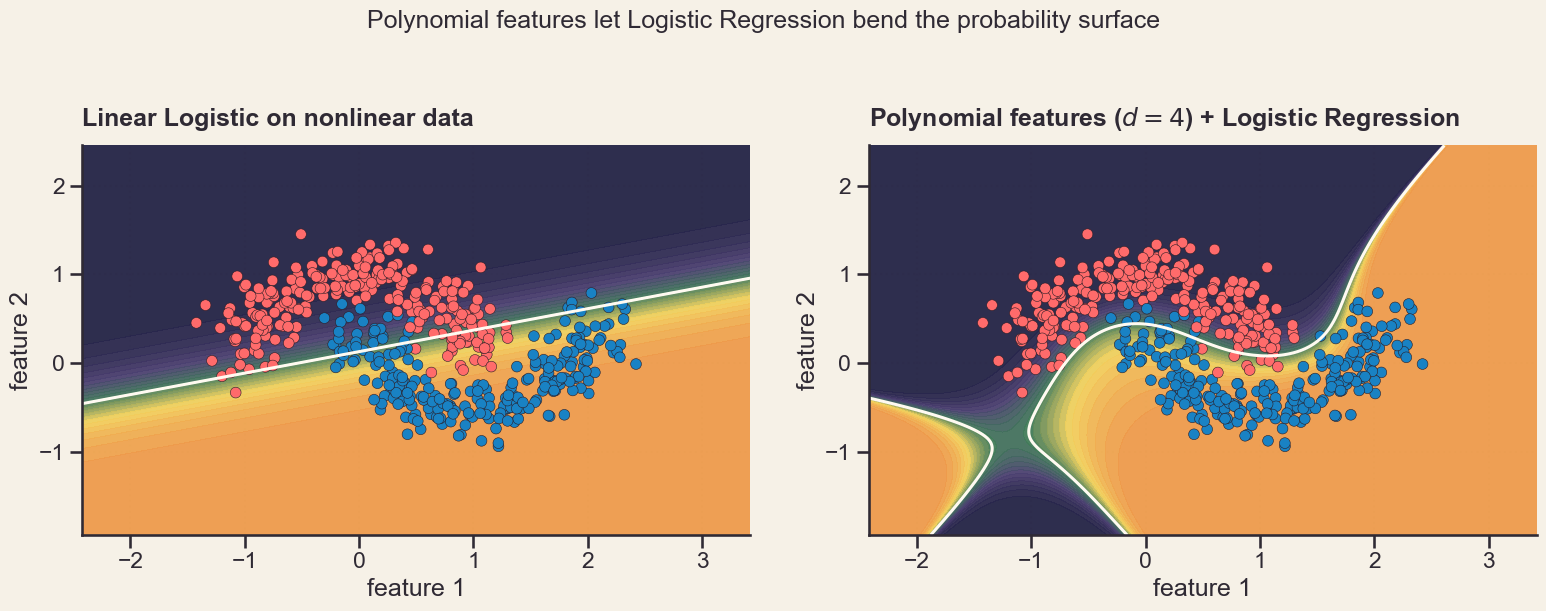

model,Linear Logistic,Polynomial Logistic
metric,,
accuracy,0.864,0.984
f1,0.862,0.984
precision,0.869,1.000
recall,0.855,0.968
roc_auc,0.948,0.996


In [27]:
X_poly_lr, y_poly_lr = make_moons(n_samples=500, noise=0.18, random_state=42)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly_lr,
    y_poly_lr,
    test_size=0.25,
    stratify=y_poly_lr,
    random_state=42,
)

logreg_base = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)

logreg_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)

logreg_base.fit(X_train_poly, y_train_poly)
logreg_poly.fit(X_train_poly, y_train_poly)

pred_base = logreg_base.predict(X_test_poly)
proba_base = logreg_base.predict_proba(X_test_poly)[:, 1]
pred_poly = logreg_poly.predict(X_test_poly)
proba_poly = logreg_poly.predict_proba(X_test_poly)[:, 1]

poly_compare = pd.concat(
    [
        metric_frame(y_test_poly, pred_base, proba_base).assign(model="Linear Logistic"),
        metric_frame(y_test_poly, pred_poly, proba_poly).assign(model="Polynomial Logistic"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_surface(axes[0], logreg_base, X_poly_lr, y_poly_lr, "Linear Logistic on nonlinear data")
plot_surface(
    axes[1],
    logreg_poly,
    X_poly_lr,
    y_poly_lr,
    r"Polynomial features ($d=4$) + Logistic Regression",
)
fig.suptitle("Polynomial features let Logistic Regression bend the probability surface", y=1.03, fontsize=18)
fig.tight_layout()
plt.show()

poly_compare.pivot(index="metric", columns="model", values="value").round(3)


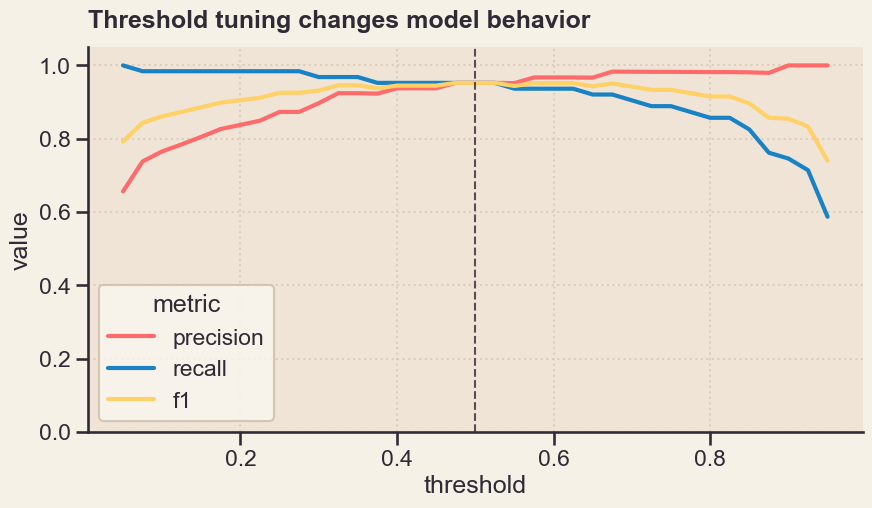

,threshold,precision,recall,f1
18,0.500,0.952,0.952,0.952
19,0.525,0.952,0.952,0.952
17,0.475,0.952,0.952,0.952
22,0.600,0.967,0.937,0.952
23,0.625,0.967,0.937,0.952
21,0.575,0.967,0.937,0.952
25,0.675,0.983,0.921,0.951
12,0.350,0.924,0.968,0.946


In [28]:
thresholds = np.linspace(0.05, 0.95, 37)
threshold_rows = []

for threshold in thresholds:
    pred_t = (proba_lin >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test_lin, pred_t, zero_division=0),
            "recall": recall_score(y_test_lin, pred_t, zero_division=0),
            "f1": f1_score(y_test_lin, pred_t, zero_division=0),
        }
    )

threshold_frame = pd.DataFrame(threshold_rows)
threshold_plot = threshold_frame.melt(
    id_vars="threshold", var_name="metric", value_name="value"
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=threshold_plot,
    x="threshold",
    y="value",
    hue="metric",
    linewidth=3,
    ax=ax,
)
ax.axvline(0.5, color="#5c4b51", linestyle="--", linewidth=1.5)
ax.set_title("Threshold tuning changes model behavior")
ax.set_ylim(0.0, 1.05)
plt.show()

threshold_frame.sort_values("f1", ascending=False).head(8).round(3)


### Interpreting coefficients

With standardized features:

$$
\Delta \log \frac{p}{1-p} = w_j \, \Delta x_j
$$

and the odds multiplier is

$$
\exp(w_j)
$$

So a coefficient acts on **log-odds**, not directly on probability.


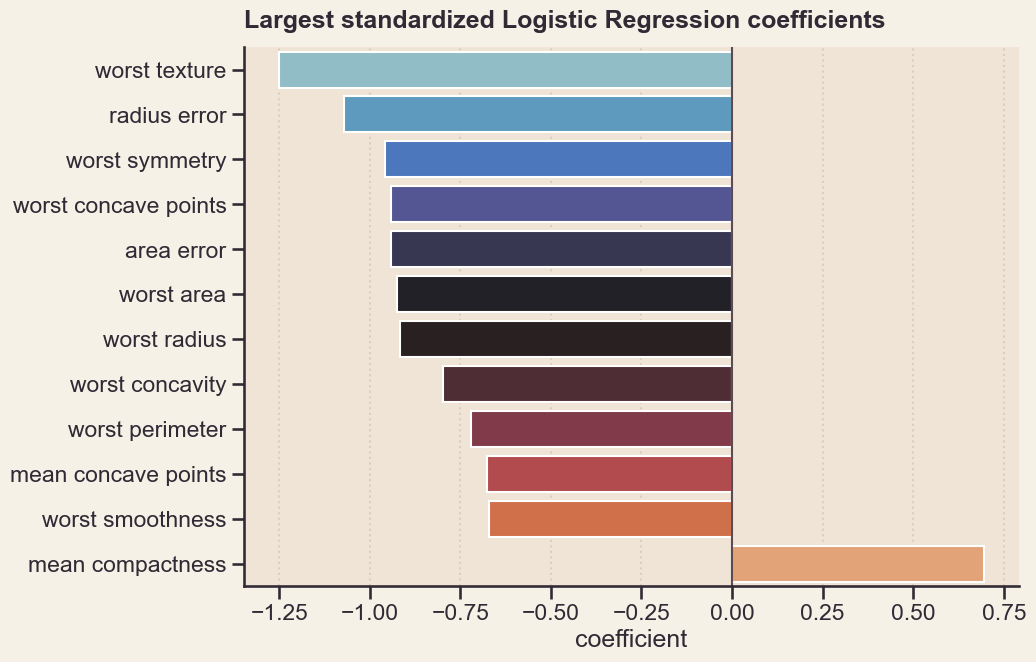

,feature,coef,odds_multiplier
21,worst texture,-1.250,0.286
10,radius error,-1.070,0.343
28,worst symmetry,-0.957,0.384
27,worst concave points,-0.942,0.390
13,area error,-0.941,0.390
23,worst area,-0.926,0.396
20,worst radius,-0.917,0.400
26,worst concavity,-0.797,0.451
22,worst perimeter,-0.721,0.486
7,mean concave points,-0.677,0.508


In [29]:
breast = load_breast_cancer()
X_breast = pd.DataFrame(breast.data, columns=breast.feature_names)
y_breast = pd.Series(breast.target, name="target")

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_breast,
    y_breast,
    test_size=0.25,
    stratify=y_breast,
    random_state=42,
)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)

logreg_coef = LogisticRegression(max_iter=4000)
logreg_coef.fit(X_train_b_scaled, y_train_b)

coef_frame = pd.DataFrame(
    {
        "feature": X_breast.columns,
        "coef": logreg_coef.coef_[0],
    }
)
coef_frame["abs_coef"] = coef_frame["coef"].abs()
coef_frame["odds_multiplier"] = np.exp(coef_frame["coef"])

top_coef = (
    coef_frame.sort_values("abs_coef", ascending=False)
    .head(12)
    .sort_values("coef")
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=top_coef,
    x="coef",
    y="feature",
    hue="feature",
    palette=sns.color_palette("icefire", len(top_coef)),
    dodge=False,
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#5c4b51", linewidth=1.5)
ax.set_title("Largest standardized Logistic Regression coefficients")
ax.set_xlabel("coefficient")
ax.set_ylabel("")
plt.show()

top_coef[["feature", "coef", "odds_multiplier"]].round(3)


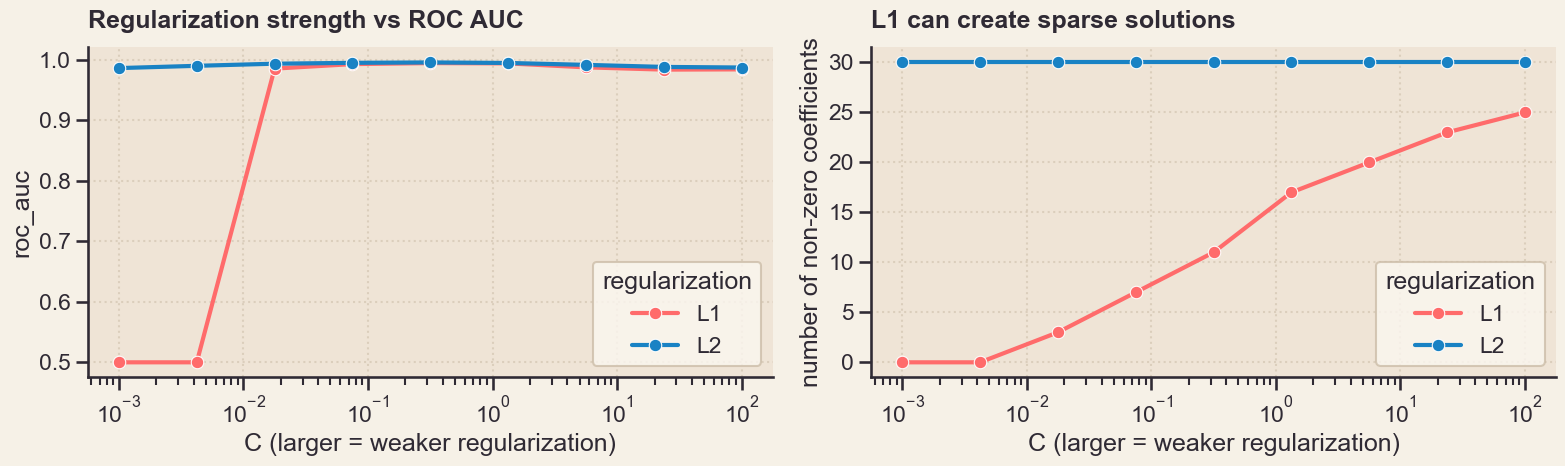

In [30]:
C_grid = np.logspace(-3, 2, 9)
reg_rows = []

for regularization, solver, l1_ratio in [("L1", "liblinear", 1.0), ("L2", "lbfgs", 0.0)]:
    for C in C_grid:
        model = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(solver=solver, l1_ratio=l1_ratio, C=C, max_iter=4000)),
            ]
        )
        cv_scores = cross_validate(
            model,
            X_breast,
            y_breast,
            cv=5,
            scoring={"roc_auc": "roc_auc", "accuracy": "accuracy"},
        )
        model.fit(X_train_b, y_train_b)
        coef = model.named_steps["model"].coef_[0]
        reg_rows.append(
            {
                "regularization": regularization,
                "C": C,
                "roc_auc": cv_scores["test_roc_auc"].mean(),
                "accuracy": cv_scores["test_accuracy"].mean(),
                "non_zero_coef": np.count_nonzero(np.abs(coef) > 1e-8),
            }
        )

reg_frame = pd.DataFrame(reg_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=reg_frame,
    x="C",
    y="roc_auc",
    hue="regularization",
    marker="o",
    linewidth=3,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Regularization strength vs ROC AUC")
axes[0].set_xlabel("C (larger = weaker regularization)")

sns.lineplot(
    data=reg_frame,
    x="C",
    y="non_zero_coef",
    hue="regularization",
    marker="o",
    linewidth=3,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("L1 can create sparse solutions")
axes[1].set_xlabel("C (larger = weaker regularization)")
axes[1].set_ylabel("number of non-zero coefficients")

fig.tight_layout()
plt.show()


### Multiclass Logistic Regression

For more than two classes, the softmax version is

$$
P(y=k \mid x) =
\frac{\exp(w_k^\top x + b_k)}
{\sum_{j=1}^{K} \exp(w_j^\top x + b_j)}
$$

Same idea, just one score per class.


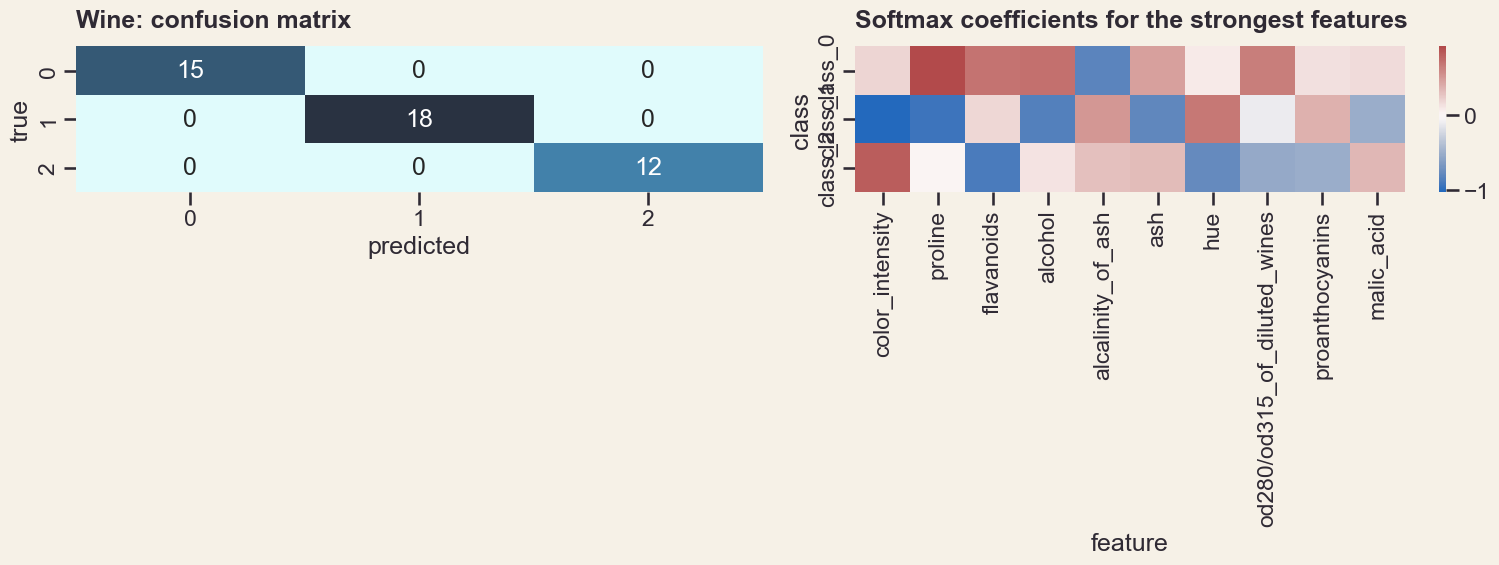

,metric,value
0,accuracy,1.0


In [31]:
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine,
    y_wine,
    test_size=0.25,
    stratify=y_wine,
    random_state=42,
)

wine_logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000, solver="lbfgs", l1_ratio=0.0)),
    ]
)
wine_logreg.fit(X_train_w, y_train_w)
pred_wine = wine_logreg.predict(X_test_w)

cm_wine = confusion_matrix(y_test_w, pred_wine)
coef_wine = pd.DataFrame(
    wine_logreg.named_steps["model"].coef_,
    columns=X_wine.columns,
    index=wine.target_names,
)
top_wine_features = coef_wine.abs().mean(axis=0).sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(
    cm_wine,
    annot=True,
    fmt="d",
    cmap=cool_cmap,
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Wine: confusion matrix")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")

sns.heatmap(
    coef_wine[top_wine_features],
    cmap="vlag",
    center=0,
    ax=axes[1],
)
axes[1].set_title("Softmax coefficients for the strongest features")
axes[1].set_xlabel("feature")
axes[1].set_ylabel("class")

fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "metric": ["accuracy"],
        "value": [accuracy_score(y_test_w, pred_wine)],
    }
).round(3)


## 3. Support Vector Machine

Linear SVM uses a score

$$
f(x) = w^\top x + b
$$

and predicts by the sign of that score.  
The geometric margin is

$$
\text{margin} = \frac{2}{\lVert w \rVert}
$$

With labels encoded as $y \in \{-1, +1\}$, the hinge loss is

$$
L_{\text{hinge}}(y, f(x)) = \max(0, 1 - y f(x))
$$

Support vectors are the points that define the boundary.


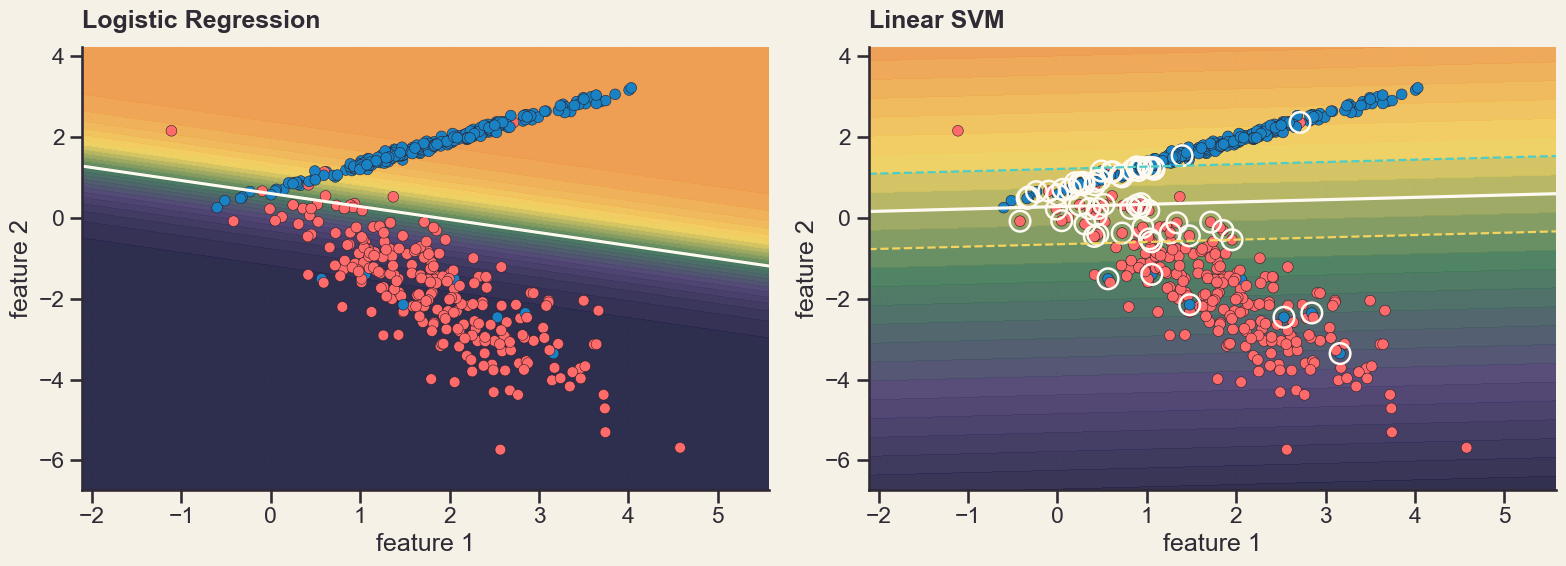

model,Linear SVM,Logistic Regression
metric,,
accuracy,0.968,0.952
f1,0.969,0.952
precision,0.954,0.952
recall,0.984,0.952
roc_auc,0.980,0.986


In [32]:
linear_svm = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1.0)),
    ]
)
linear_svm.fit(X_train_lin, y_train_lin)

pred_svm_lin = linear_svm.predict(X_test_lin)
score_svm_lin = linear_svm.decision_function(X_test_lin)

model_compare = pd.concat(
    [
        metric_frame(y_test_lin, pred_lin, proba_lin).assign(model="Logistic Regression"),
        metric_frame(y_test_lin, pred_svm_lin, score_svm_lin).assign(model="Linear SVM"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_surface(axes[0], logreg_lin, X_lin, y_lin, "Logistic Regression")
plot_margin_surface(axes[1], linear_svm, X_lin, y_lin, "Linear SVM", show_support=True)
fig.tight_layout()
plt.show()

model_compare.pivot(index="metric", columns="model", values="value").round(3)


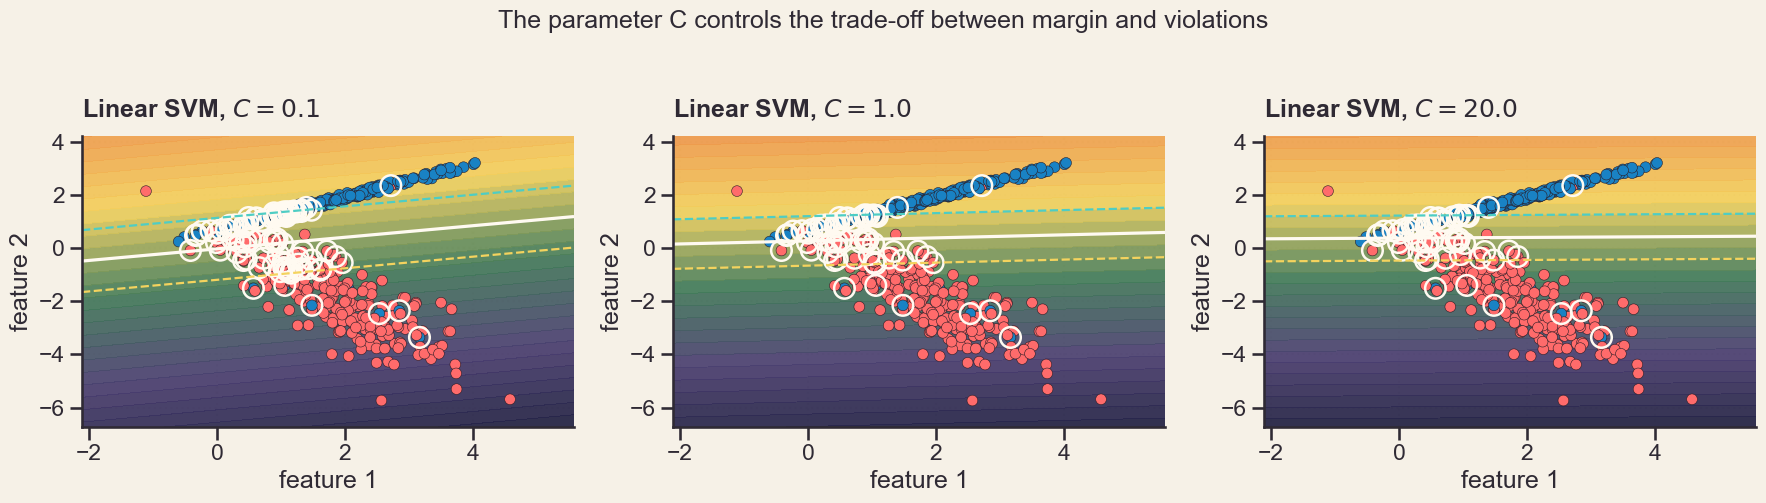

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, C in zip(axes, [0.1, 1.0, 20.0]):
    svm_c = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="linear", C=C)),
        ]
    )
    svm_c.fit(X_train_lin, y_train_lin)
    plot_margin_surface(ax, svm_c, X_lin, y_lin, rf"Linear SVM, $C={C}$", show_support=True)

fig.suptitle("The parameter C controls the trade-off between margin and violations", y=1.02, fontsize=18)
fig.tight_layout()
plt.show()


### Kernel trick

Instead of mapping features explicitly, SVM can work through a kernel:

$$
K(x_i, x_j) = \phi(x_i)^\top \phi(x_j)
$$

The most popular one is the RBF kernel:

$$
K(x_i, x_j) = \exp\left(-\gamma \lVert x_i - x_j \rVert^2 \right)
$$

Here $\gamma$ controls how local or global each point's influence is.


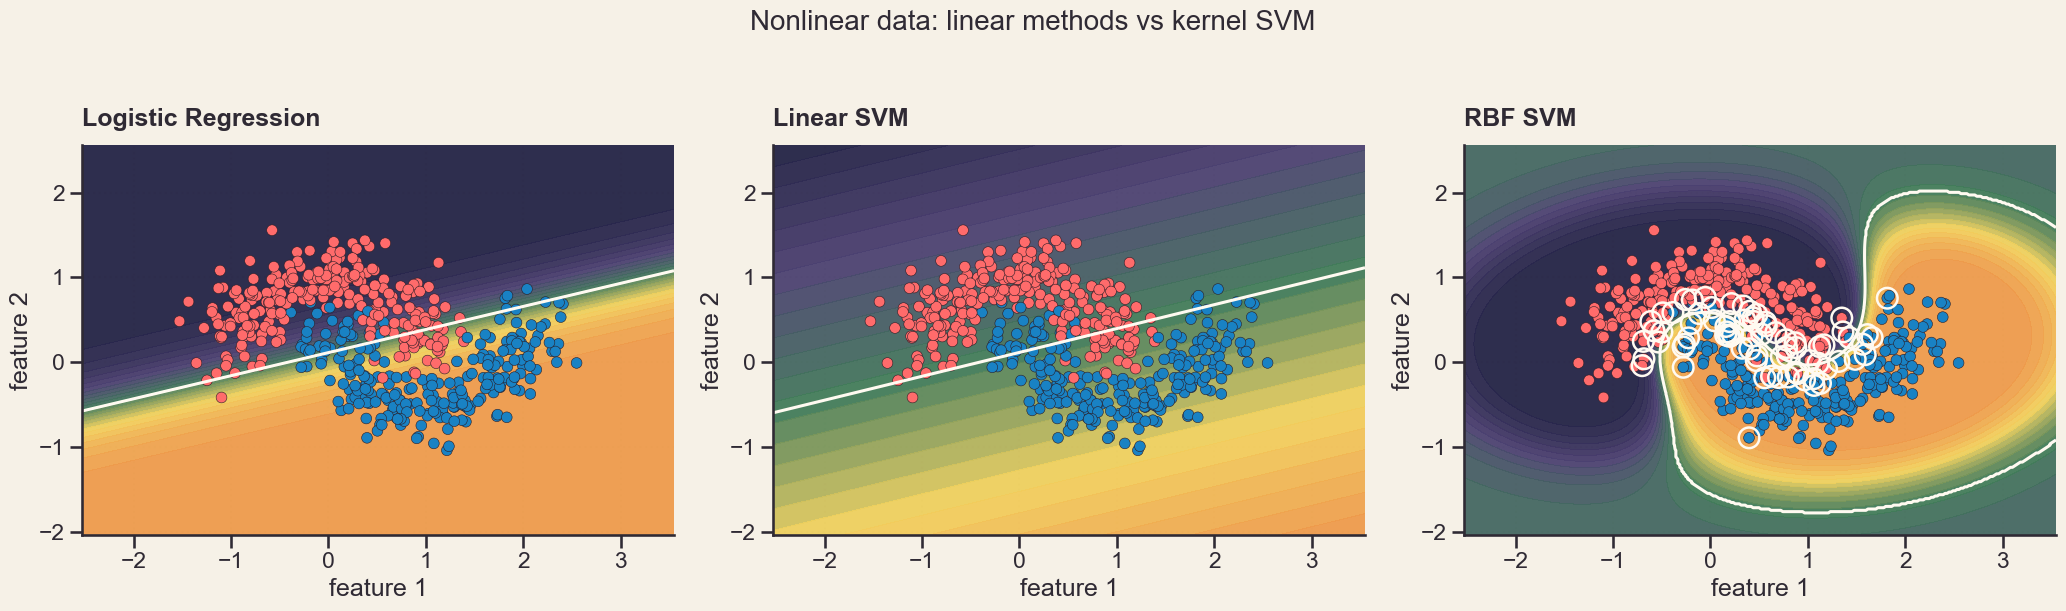

,model,accuracy,f1,roc_auc
0,Logistic Regression,0.856,0.852,0.941
1,Linear SVM,0.856,0.852,0.942
2,RBF SVM,0.984,0.984,0.997


In [34]:
X_moon, y_moon = make_moons(n_samples=500, noise=0.22, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moon,
    y_moon,
    test_size=0.25,
    stratify=y_moon,
    random_state=42,
)

moon_models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000)),
        ]
    ),
    "Linear SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LinearSVC(C=1.0, max_iter=10000)),
        ]
    ),
    "RBF SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, random_state=42)),
        ]
    ),
}

moon_rows = []
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (name, model) in zip(axes, moon_models.items()):
    model.fit(X_train_m, y_train_m)
    pred = model.predict(X_test_m)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test_m)[:, 1]
    else:
        score = model.decision_function(X_test_m)

    moon_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test_m, pred),
            "f1": f1_score(y_test_m, pred),
            "roc_auc": roc_auc_score(y_test_m, score),
        }
    )

    if name == "RBF SVM":
        plot_surface(ax, model, X_moon, y_moon, name, show_support=True)
    else:
        plot_surface(ax, model, X_moon, y_moon, name)

fig.suptitle("Nonlinear data: linear methods vs kernel SVM", y=1.03, fontsize=20)
fig.tight_layout()
plt.show()

pd.DataFrame(moon_rows).round(3)


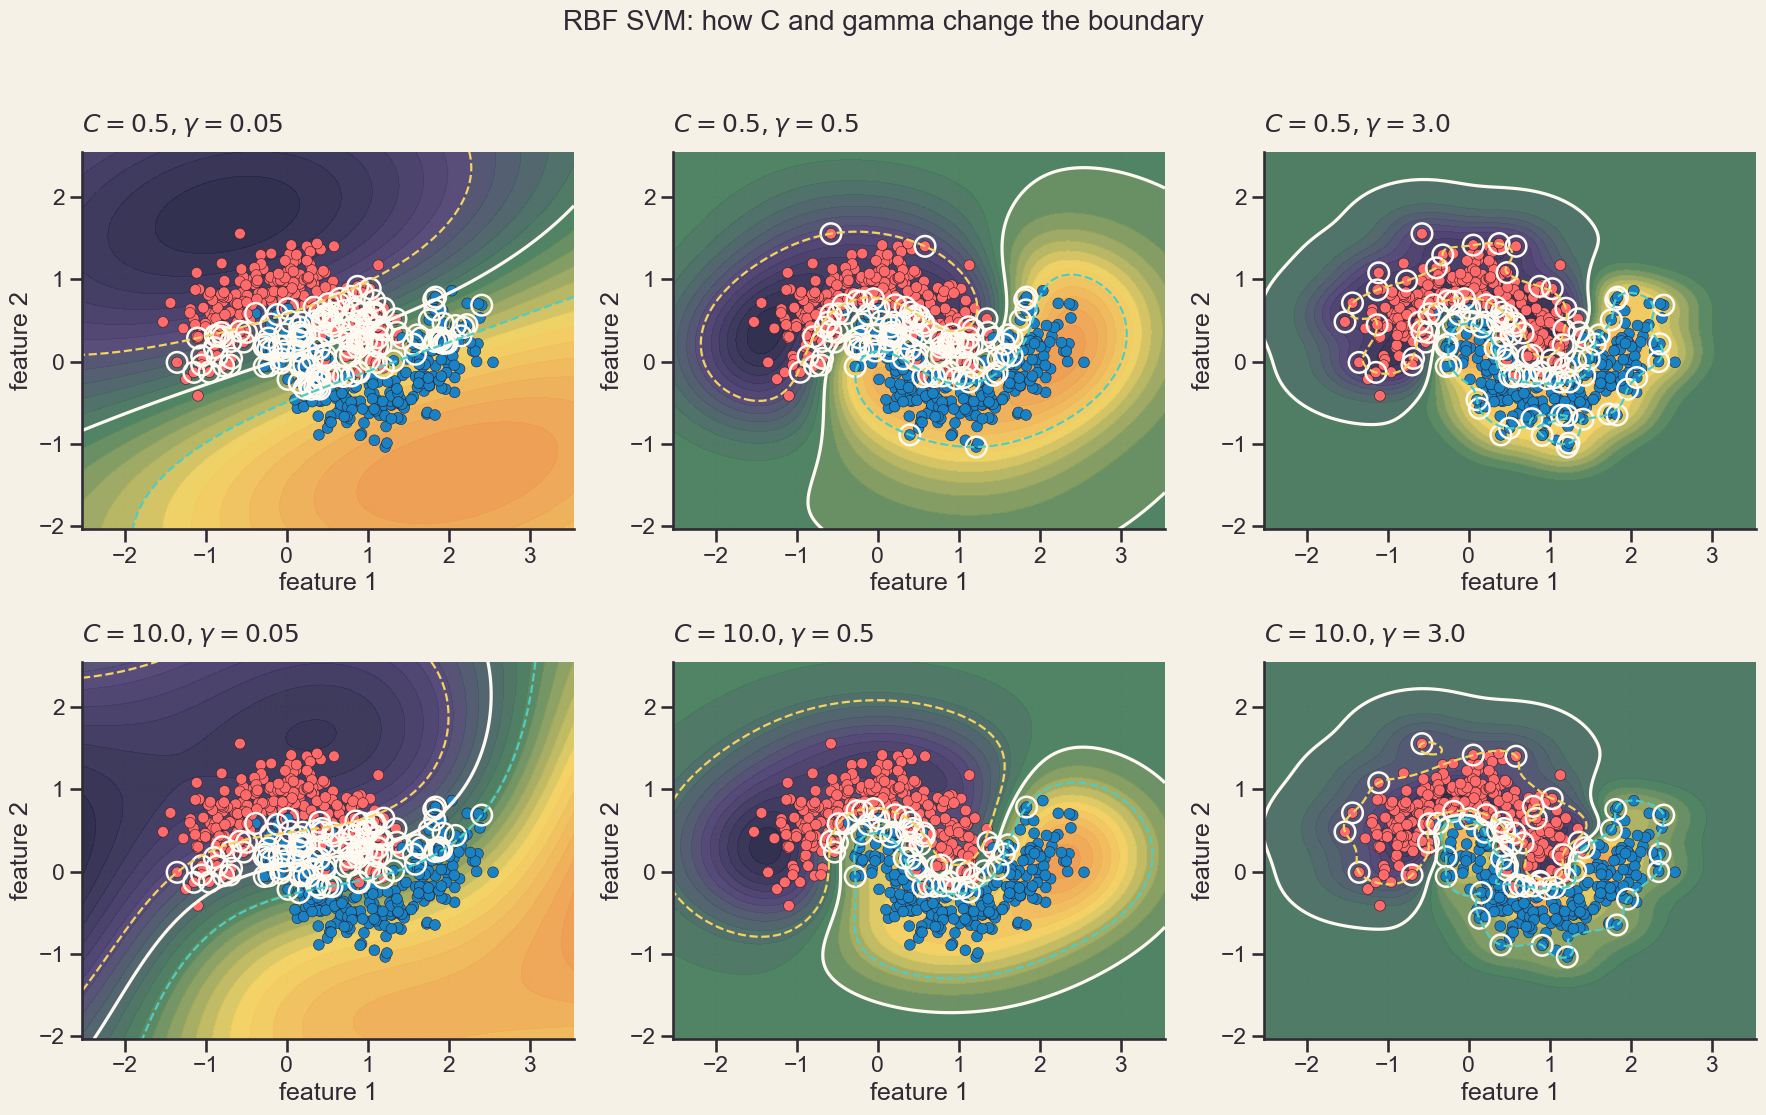

In [35]:
sweep_params = [
    (0.5, 0.05),
    (0.5, 0.5),
    (0.5, 3.0),
    (10.0, 0.05),
    (10.0, 0.5),
    (10.0, 3.0),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, (C, gamma) in zip(axes.flat, sweep_params):
    svm_rbf = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=C, gamma=gamma)),
        ]
    )
    svm_rbf.fit(X_train_m, y_train_m)
    plot_margin_surface(ax, svm_rbf, X_moon, y_moon, rf"$C={C}, \gamma={gamma}$")

fig.suptitle("RBF SVM: how C and gamma change the boundary", y=1.02, fontsize=20)
fig.tight_layout()
plt.show()


## 4. Real data benchmark

On tabular binary classification, Logistic Regression and SVM are both strong baselines.

The usual workflow:
- standardize features;
- compare with cross-validation;
- then tune $C$ and, for RBF SVM, also $\gamma$.


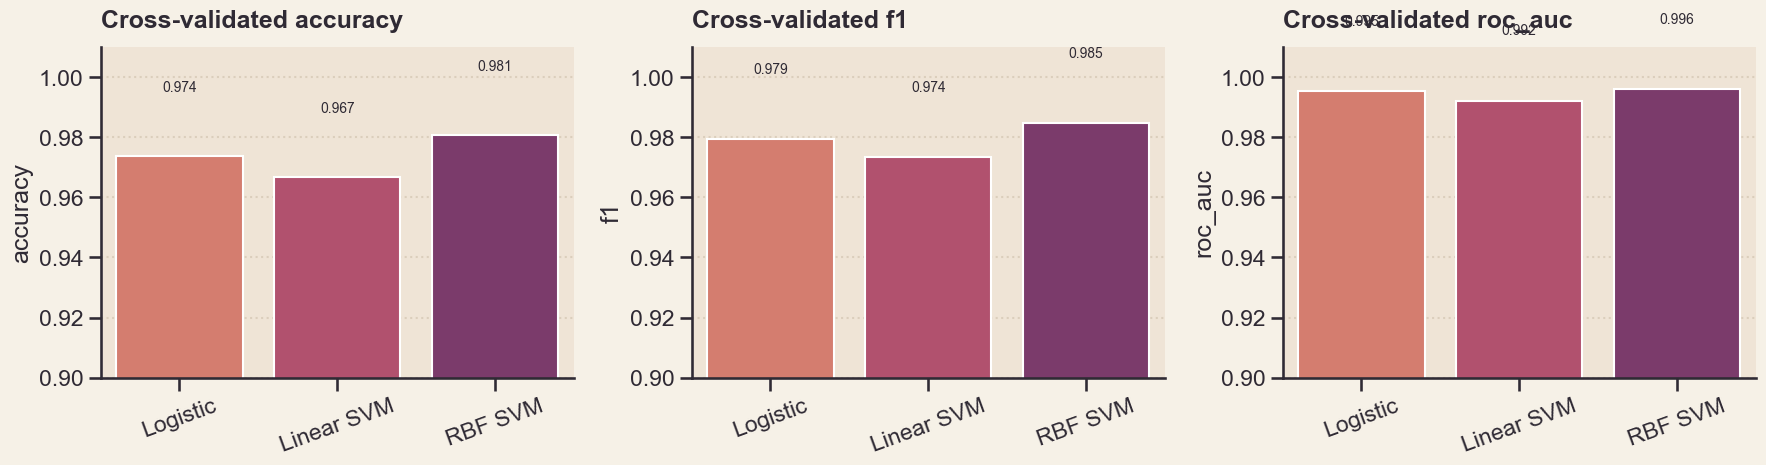

,model,accuracy,f1,roc_auc
0,Logistic,0.974,0.979,0.995
1,Linear SVM,0.967,0.974,0.992
2,RBF SVM,0.981,0.985,0.996


In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

benchmark_models = {
    "Logistic": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=4000)),
        ]
    ),
    "Linear SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LinearSVC(C=1.0, max_iter=10000)),
        ]
    ),
    "RBF SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, random_state=42)),
        ]
    ),
}

bench_rows = []
for name, model in benchmark_models.items():
    scores = cross_validate(
        model,
        X_breast,
        y_breast,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"},
    )
    bench_rows.append(
        {
            "model": name,
            "accuracy": scores["test_accuracy"].mean(),
            "f1": scores["test_f1"].mean(),
            "roc_auc": scores["test_roc_auc"].mean(),
        }
    )

bench = pd.DataFrame(bench_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    sns.barplot(
        data=bench,
        x="model",
        y=metric,
        hue="model",
        palette="flare",
        dodge=False,
        legend=False,
        ax=ax,
    )
    annotate_bars(ax)
    ax.set_ylim(0.9, 1.01)
    ax.set_title(f"Cross-validated {metric}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

bench.round(3)


In [37]:
logreg_grid = GridSearchCV(
    estimator=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=4000)),
        ]
    ),
    param_grid=[
        {
            "model__solver": ["lbfgs"],
            "model__l1_ratio": [0.0],
            "model__C": [0.01, 0.1, 1.0, 10.0],
        },
        {
            "model__solver": ["liblinear"],
            "model__l1_ratio": [0.0, 1.0],
            "model__C": [0.01, 0.1, 1.0, 10.0],
        },
    ],
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

logreg_grid.fit(X_train_b, y_train_b)

logreg_results = pd.DataFrame(logreg_grid.cv_results_)[
    [
        "param_model__solver",
        "param_model__l1_ratio",
        "param_model__C",
        "mean_test_score",
        "rank_test_score",
    ]
].copy()
logreg_results["regularization"] = (
    logreg_results["param_model__l1_ratio"].astype(float).map({0.0: "L2", 1.0: "L1"})
)
logreg_results = logreg_results[
    [
        "param_model__solver",
        "regularization",
        "param_model__C",
        "mean_test_score",
        "rank_test_score",
    ]
].sort_values(["rank_test_score", "param_model__C"])

logreg_results.head(10).round(3)


,param_model__solver,regularization,param_model__C,mean_test_score,rank_test_score
2,lbfgs,L2,1.00,0.996,1
8,liblinear,L2,1.00,0.996,1
9,liblinear,L1,1.00,0.996,3
6,liblinear,L2,0.10,0.996,4
1,lbfgs,L2,0.10,0.995,5
4,liblinear,L2,0.01,0.993,6
0,lbfgs,L2,0.01,0.993,7
7,liblinear,L1,0.10,0.992,8
10,liblinear,L2,10.00,0.990,9
3,lbfgs,L2,10.00,0.990,10


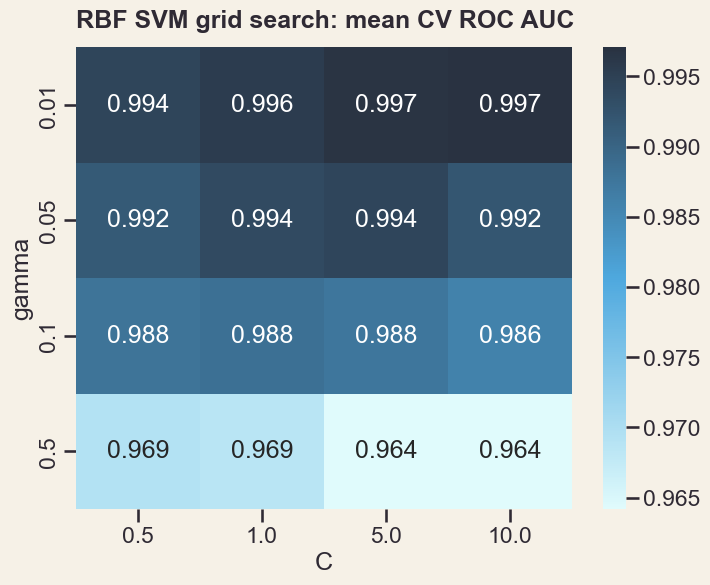

model__C        10.00
model__gamma     0.01
dtype: float64

In [38]:
svc_grid = GridSearchCV(
    estimator=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=42)),
        ]
    ),
    param_grid={
        "model__C": [0.5, 1.0, 5.0, 10.0],
        "model__gamma": [0.01, 0.05, 0.1, 0.5],
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

svc_grid.fit(X_train_b, y_train_b)

svc_heatmap = pd.DataFrame(svc_grid.cv_results_).pivot(
    index="param_model__gamma",
    columns="param_model__C",
    values="mean_test_score",
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(svc_heatmap, annot=True, fmt=".3f", cmap=cool_cmap, ax=ax)
ax.set_title("RBF SVM grid search: mean CV ROC AUC")
ax.set_xlabel("C")
ax.set_ylabel("gamma")
plt.show()

pd.Series(svc_grid.best_params_)


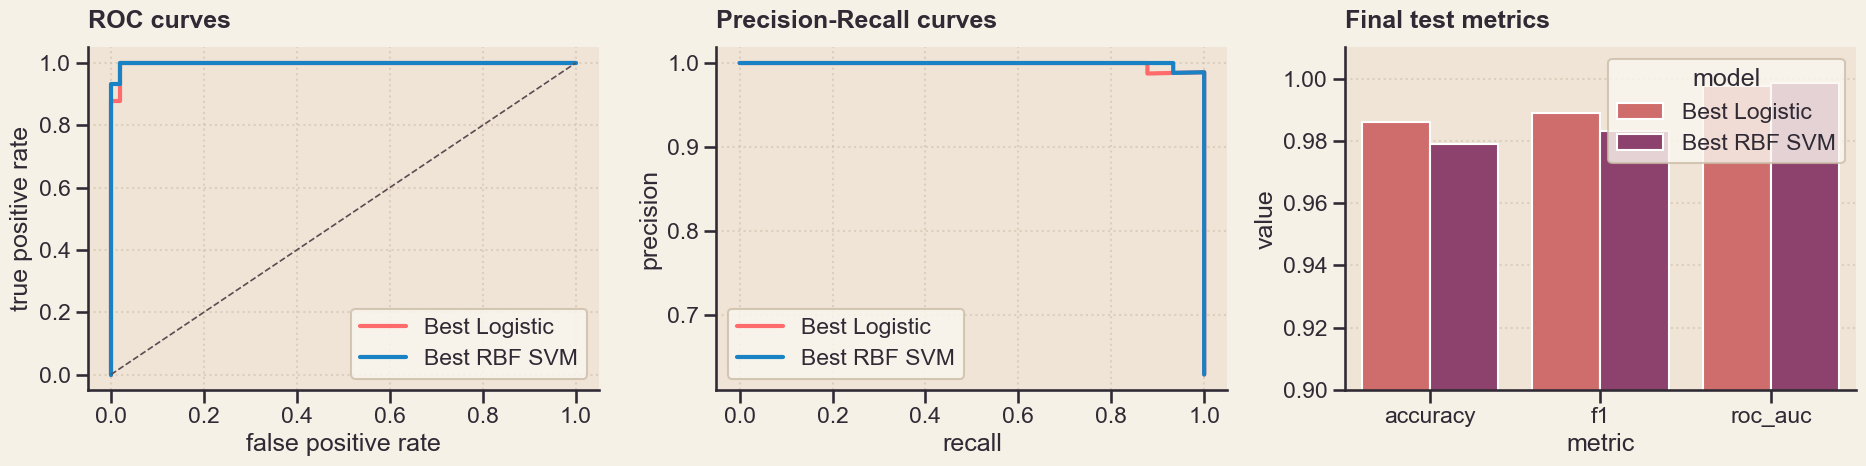

,model,accuracy,f1,roc_auc
0,Best Logistic,0.986,0.989,0.998
1,Best RBF SVM,0.979,0.983,0.999


In [39]:
best_logreg = logreg_grid.best_estimator_
best_svc = svc_grid.best_estimator_

best_logreg.fit(X_train_b, y_train_b)
best_svc.fit(X_train_b, y_train_b)

pred_best_lr = best_logreg.predict(X_test_b)
pred_best_svc = best_svc.predict(X_test_b)
proba_best_lr = best_logreg.predict_proba(X_test_b)[:, 1]
proba_best_svc = best_svc.predict_proba(X_test_b)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test_b, proba_best_lr)
fpr_svc, tpr_svc, _ = roc_curve(y_test_b, proba_best_svc)
prec_lr, rec_lr, _ = precision_recall_curve(y_test_b, proba_best_lr)
prec_svc, rec_svc, _ = precision_recall_curve(y_test_b, proba_best_svc)

final_metrics = pd.DataFrame(
    [
        {
            "model": "Best Logistic",
            "accuracy": accuracy_score(y_test_b, pred_best_lr),
            "f1": f1_score(y_test_b, pred_best_lr),
            "roc_auc": roc_auc_score(y_test_b, proba_best_lr),
        },
        {
            "model": "Best RBF SVM",
            "accuracy": accuracy_score(y_test_b, pred_best_svc),
            "f1": f1_score(y_test_b, pred_best_svc),
            "roc_auc": roc_auc_score(y_test_b, proba_best_svc),
        },
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(fpr_lr, tpr_lr, linewidth=3, label="Best Logistic")
axes[0].plot(fpr_svc, tpr_svc, linewidth=3, label="Best RBF SVM")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#5c4b51", linewidth=1.2)
axes[0].set_title("ROC curves")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend()

axes[1].plot(rec_lr, prec_lr, linewidth=3, label="Best Logistic")
axes[1].plot(rec_svc, prec_svc, linewidth=3, label="Best RBF SVM")
axes[1].set_title("Precision-Recall curves")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].legend()

sns.barplot(
    data=final_metrics.melt(id_vars="model", var_name="metric", value_name="value"),
    x="metric",
    y="value",
    hue="model",
    palette="flare",
    ax=axes[2],
)
axes[2].set_ylim(0.9, 1.01)
axes[2].set_title("Final test metrics")

fig.tight_layout()
plt.show()

final_metrics.round(3)


## Takeaways

- Classification learns from labeled examples and predicts labels for new objects.
- Logistic Regression gives a linear decision boundary and natural probabilities.
- SVM focuses on margin; support vectors determine the boundary.
- Standardization is essential for SVM and usually helpful for Logistic Regression.
- Logistic Regression is easier to explain; RBF SVM is often stronger on curved boundaries.
- In practice, tune the model **and** tune the decision threshold.


## Suggested exercises

1. Repeat the lecture without `StandardScaler` and compare all results.
2. For Logistic Regression, choose the threshold that maximizes recall instead of F1.
3. On `make_moons`, try a denser grid of $\gamma$ values and watch the boundary overfit.
4. Add `class_weight="balanced"` and test what changes on imbalanced synthetic data.
5. Compare `LinearSVC` and `SVC(kernel="linear")` on runtime and quality.


0 - 10000000000000

In [ ]:
0 - 1

In [1]:
%%time 
print(1)

1
CPU times: user 85 μs, sys: 33 μs, total: 118 μs
Wall time: 124 μs


In [ ]:
                                            
# appnope==0.1.4
# asttokens==3.0.1
# comm==0.2.3
# contourpy==1.3.3
# cycler==0.12.1
# debugpy==1.8.20
# decorator==5.2.1
# executing==2.2.1
# fonttools==4.62.1
# ipykernel==7.2.0
# ipython==9.12.0
# ipython_pygments_lexers==1.1.1
# jedi==0.19.2
# joblib==1.5.3
# jupyter_client==8.8.0
# jupyter_core==5.9.1
# kiwisolver==1.5.0
# matplotlib==3.10.8
# matplotlib-inline==0.2.1
# nest-asyncio==1.6.0
# numpy==2.4.4
# packaging==26.0
# pandas==3.0.1
# parso==0.8.6
# pexpect==4.9.0
# pillow==12.1.1
# platformdirs==4.9.4
# prompt_toolkit==3.0.52
# psutil==7.2.2
# ptyprocess==0.7.0
# pure_eval==0.2.3
# Pygments==2.20.0
# pyparsing==3.3.2
# python-dateutil==2.9.0.post0
# pyzmq==27.1.0
# scikit-learn==1.8.0
# scipy==1.17.1
# seaborn==0.13.2
# six==1.17.0
# stack-data==0.6.3
# threadpoolctl==3.6.0
# tornado==6.5.5
# traitlets==5.14.3
# wcwidth==0.6.0